In [1]:
import os
user = 'YS' if os.environ['USER'] in ['yitians', 'sunyitian'] else ''

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
import scipy.integrate as integrate
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%reload_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params, params_alt
if user == 'YS':
    params = params_alt # '...' is not a valid rc parameter error

warnings.filterwarnings("ignore", category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

In [6]:
! nvidia-smi

Wed Oct 19 09:20:02 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   37C    P0    36W / 250W |  29295MiB / 32768MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## 1. _Fermi_ data

In [11]:
# Load and downsamples Fermi counts data

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [8]:
# Load and downsample exposure

exposure = fits.open("../data/exposure_ultracleanveto_bestpsf_joined.fits")
exposure = exposure[0].data[:, int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exposure.shape[1] // upsample_factor

In [9]:
# Interpolate exposure to the Zenodo map energy bins

e_min_interp = np.array(counts_fits[1].data[:])['E_MIN'] / 1e3
exposure_interp = interp1d(e_min_interp, exposure, axis=0)
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) 
exposure_interp = exposure_interp(e_bins).reshape(len(e_bins), -1, upsample_factor, b, upsample_factor).mean((-1, -3))

## 2. Templates

In [10]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

In [11]:
# Load standard templates and convert to Cartesian
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5)) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5)) > 0

In [12]:
np.max(counts_downsampled[~mask_roi])

147

### 2.1 Pixel area map
Our RoI is $|l|<20^\circ$ and $|b|<20^\circ$ with pixel size of $0.5^\circ$.

In [13]:
theta_edges = np.linspace(70*np.pi/180, 110*np.pi/180, 81)
theta_ints = np.cos(theta_edges[:-1]) - np.cos(theta_edges[1:])
pixel_area_map = np.array([theta_int * np.full((80,), 0.5*np.pi/180) for theta_int in theta_ints])
print(f'{np.max(pixel_area_map):.3e}, {np.min(pixel_area_map):.3e}')

7.615e-05, 7.167e-05


### SkyFACT
RoI is $|l|\le90^\circ$ and $|b|\le20.25^\circ$. \
Pixel size is $0.5^\circ$, image shape is (81, 360).

In [8]:
names = ['ICS', 'pi0ii', 'pi0i', 'pi0o']
names_paper = ['ICS', 'Gas_ring_I', 'Gas_ring_II', 'Gas_ring_III']

<ipython-input-10-743bb821be74>:6: RuntimeWarning: divide by zero encountered in log10
  im = axs[i].imshow(np.flipud(np.log10(image)), cmap='cubehelix',


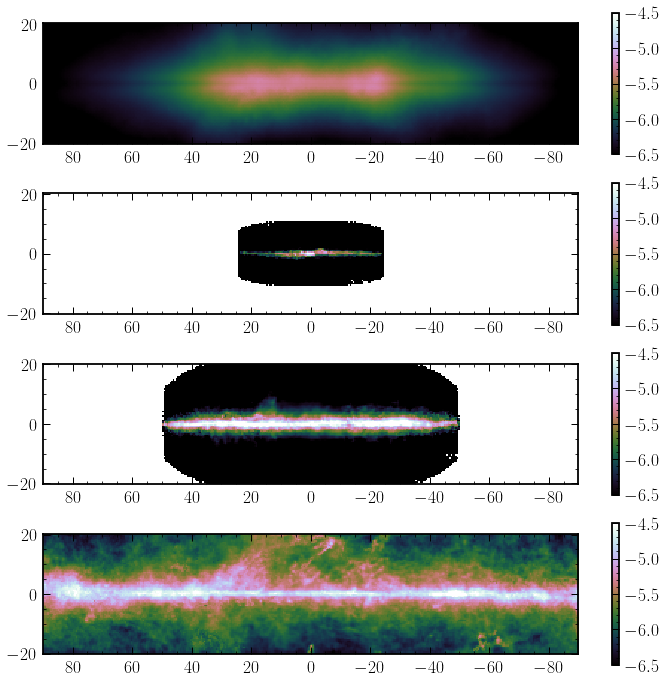

In [10]:
# view templates
fig, axs = plt.subplots(4, 1, figsize=(12,12))

for i, name in enumerate(names):
    image = np.loadtxt(f'../data/external/SkyFACT/r5_map_mean_model_{name}_2_20.dat')
    im = axs[i].imshow(np.flipud(np.log10(image)), cmap='cubehelix',
                       extent=(90,-90,-20.25,20.25), vmin=-6.5, vmax=-4.5)
    # axs[i].set(ylabel=r'$b$ [$^\circ$]')
    # axs[i].set(title=names_paper[i]+'('+name+') $\log_{10}\Phi/$photon cm$^{-1}$s$^{-1}$sr$^{-1}$')
    fig.colorbar(im, ax=axs[i])
# axs[-1].set(xlabel=r'$l$ [$^\circ$]');

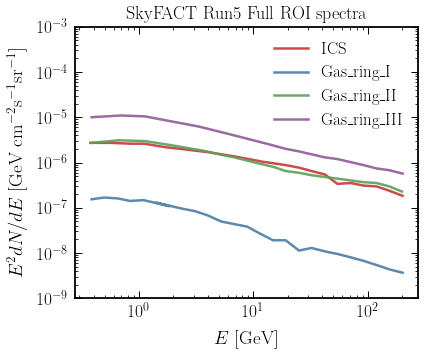

In [16]:
# view ICS and pi spectra
fig, ax = plt.subplots()

for p in names_paper:
    eng, E2dNdE = 10**np.loadtxt(f'../data/external/SkyFACT/{p}_full.csv', unpack=True)
    ax.plot(eng, E2dNdE, label=p)
ax.set(xscale='log', yscale='log', ylim=(1e-9, 1e-3))
ax.set(xlabel=r'$E$ [GeV]', ylabel=r'$E^2dN/dE$ [GeV cm$^{-2}$s$^{-1}$sr$^{-1}$]')
ax.set(title='SkyFACT Run5 Full ROI spectra')
ax.legend();

In [17]:
def downsample(arr, f):
    """ Converts a shape (h, w) array into a (h//f, w//f) array
        by adding the values in f*f blocks.
    """
    h, w = arr.shape
    if h%f != 0 or w%f != 0:
        raise ValueError('h and w need to be multiples of f')
    return np.sum([[arr[i::f, j::f] for j in range(f)] for i in range(f)], axis=(0,1))

In [18]:
temps_SkyFACT = []

eng_bin_start, eng_bin_end = 10, 20 # 2-20 GeV
eng_bin_edge = np.array(counts_fits[1].data[eng_bin_start:eng_bin_end+1])['E_MIN'] / 1e3
print(f'{eng_bin_edge[0]:.3f}-{eng_bin_edge[-1]:.3f} GeV')

for i in range(4):
    # calculate N (summed in spatial direction) for each exposure bin
    eng, E2dNdE = 10**np.loadtxt(f'../data/external/SkyFACT/{names_paper[i]}_full.csv', unpack=True) # [GeV], [photon GeV cm^-2 s^-1 sr^-1]
    dNdE_interp = interp1d(eng, E2dNdE/eng**2) # [photon GeV^-1 cm^-2 s^-1 sr^-1]
    dNdE_func = lambda e: dNdE_interp(e).item()
    Ns = [integrate.quad(dNdE_func, eng_bin_edge[i], eng_bin_edge[i+1])[0] for i in range(10)] # [photon cm^-2 s^-1 sr^-1]
    Ns = Ns/np.sum(Ns) # [1] normalized
    # make exposure map
    exposure_weighted = np.einsum('i,ijk->jk', Ns, exposure[eng_bin_start:eng_bin_end]) # [cm^2 s^1], pixel=0.1 deg
    exposure_weighted = downsample(exposure_weighted, 5) # [cm^2 s^1], pixel=0.5 deg
    # make counts map
    phi = np.loadtxt(f'../data/external/SkyFACT/r5_map_mean_model_{names[i]}_2_20.dat') # [photon cm^-2 s^-1 sr^-1]
    phi = phi[:, int(phi.shape[1] * 70/180):int(phi.shape[1] * 110/180)]
    phi = (phi[:-1] + phi[1:])/2 # interpolate to -20 < b < 20
    phi *= exposure_weighted # [photon sr^-1]
    phi *= pixel_area_map # [photon]
    temps_SkyFACT.append(phi)
temps_SkyFACT = np.array(temps_SkyFACT)
temp_SkyFACT_ICS, temp_SkyFACT_pi0 = temps_SkyFACT[0], np.sum(temps_SkyFACT[1:], axis=0)

2.000-20.000 GeV


In [19]:
# save maps
np.save('../data/external/SkyFACT/template_SkyFACT_ICS.npy',          temp_SkyFACT_ICS)
np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_I.npy',   temps_SkyFACT[1])
np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_II.npy',  temps_SkyFACT[2])
np.save('../data/external/SkyFACT/template_SkyFACT_Gas_ring_III.npy', temps_SkyFACT[3])
np.save('../data/external/SkyFACT/template_SkyFACT_pi0.npy',          temp_SkyFACT_pi0)

/var/folders/24/spnpknrj5vb_jzkn8lgg5gth0000gn/T/ipykernel_2596/4133499368.py:6: RuntimeWarning: divide by zero encountered in log10
  im = axs[i].imshow(np.flipud(np.log10(temps_SkyFACT[i])), cmap='cubehelix',


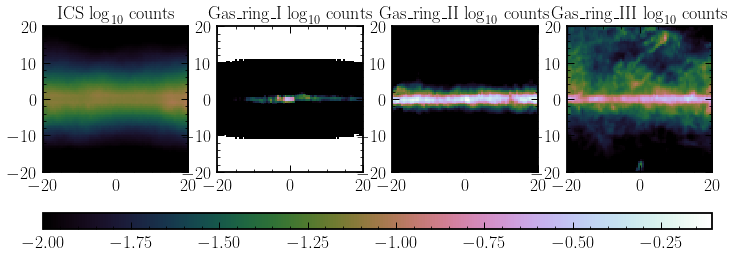

In [20]:
# view counts maps
fig, axs = plt.subplots(1, 4, figsize=(12,5))

vmin, vmax = -2, np.log10(np.max(temps_SkyFACT))
for i in range(4):
    im = axs[i].imshow(np.flipud(np.log10(temps_SkyFACT[i])), cmap='cubehelix',
                       extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
    #axs[i].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
    axs[i].set(title=names_paper[i]+' $\log_{10}$ counts')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40);

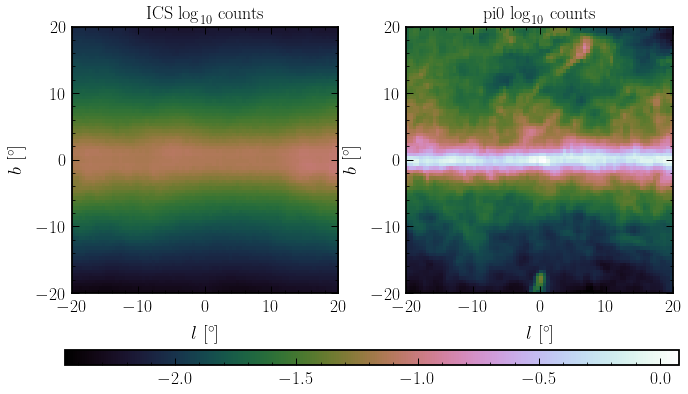

In [21]:
# view counts maps
fig, axs = plt.subplots(1, 2, figsize=(11,7))

vmin = np.log10(np.min([temp_SkyFACT_ICS, temp_SkyFACT_pi0]))
vmax = np.log10(np.max([temp_SkyFACT_ICS, temp_SkyFACT_pi0]))

im = axs[0].imshow(np.flipud(np.log10(temp_SkyFACT_ICS)), cmap='cubehelix',
                   extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
axs[0].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
axs[0].set(title='ICS $\log_{10}$ counts')

im = axs[1].imshow(np.flipud(np.log10(temp_SkyFACT_pi0)), cmap='cubehelix',
                   extent=(-20,20,-20,20), vmin=vmin, vmax=vmax)
axs[1].set(xlabel=r'$l$ [$^\circ$]', ylabel=r'$b$ [$^\circ$]')
axs[1].set(title='pi0 $\log_{10}$ counts')

fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40);

## Test opening Zenodo maps

In [22]:
zenodo_dir = "/Users/smsharma/Downloads"  # Directory where Zenodo maps are located
if user == 'YS':
    zenodo_dir = '/Users/sunyitian/Dropbox (MIT)/Documents/P/ml_GCE/templates'

In [23]:
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) / 1e3 
e_bins_widths = (e_bins[1:] - e_bins[:-1])
e_bins_centers = (e_bins[1:] + e_bins[:-1]) / 2

In [24]:
# Select energy bins closest to 2 and 20 GeV
e_bin_min_idx = np.argmin(np.abs(e_bins - 2)) #- 1
e_bin_max_idx = np.argmin(np.abs(e_bins - 20)) #- 1

In [25]:
pixel_size_data = 0.25
pixel_size_target = 0.5
extent = 20
upsample_factor = int(pixel_size_target / pixel_size_data)

In [26]:
# Names of Zenodo diffuse models
dif_names = pd.read_csv(zenodo_dir+'/ZENODO_FILES/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', skiprows=1, header=None, delim_whitespace=True)[1].tolist()

In [27]:
dif = dif_names[0]  # Test opening first model

temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

for dif_type in ['bremss', 'pi0', 'ICS']:
    file = fits.open(zenodo_dir+"/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
    phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
    n_pix_edge = int((30 - extent) / pixel_size_data)
    n_pix_total = int(2 * extent / pixel_size_data)
    phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
    b = phi.shape[1] // upsample_factor
    phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
    phi *= np.deg2rad(pixel_size_target) ** 2
    phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
    phi /= 1e3
    temp_ary.append(phi[:, ::-1])
    
temp_ary = np.array(temp_ary)
temp_ary.mean((1,2))

array([1.81963313, 2.7126427 , 1.01120003, 1.45550733, 1.01068868,
       0.03071962, 0.04897603, 0.05130707])

## Poisson fits

In [28]:
def likelihood(theta, data, mask=None):
    """ Pixel-wise product Poisson log-likelihood
    """ 
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ik, i -> k", temp_ary[:, ~mask], theta)
    return -poisson.logpmf(data[~mask], temp_sum).mean()

def likelihood_map(theta, data, mask=None):
    """ Maps of Poisson likelihood per-pixel
    """ 
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ikj, i -> kj", temp_ary, theta)
    return poisson.logpmf(data, temp_sum) * ~mask

### Standard ROI (PS + lat mask)

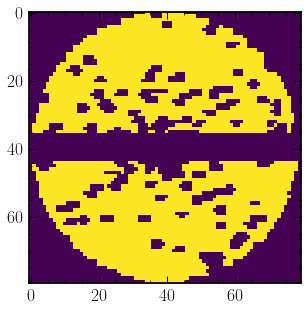

In [29]:
plt.imshow(~mask_roi);

In [30]:
ll_list = []
opt_list = []
ll_map_list = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("{}/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(zenodo_dir, dif_type, dif))
        
        # The Zenodo maps are given in E^2 dN/dE; convert them to just expected intensity

        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target) ** 2
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        #phi /= 1e3
        temp_ary.append(phi[:, ::-1])

    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)
    
    opt_list.append(opt)
    ll_list.append(ll_data) 
    ll_map_list.append(ll_map)

  0%|          | 0/80 [00:00<?, ?it/s]

In [31]:
# Do fits for p6, Model O, and SkyFACT
temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_dif_cart])
ll_p6 = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])
ll_mO = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, 1e2*temp_SkyFACT_ICS, 1e2*temp_SkyFACT_pi0])
ll_SF = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

In [32]:
ll_list_sorted = ll_list.copy()
ll_list_sorted.sort()
max_indices = [ll_list.index(ll) for ll in ll_list_sorted[-5:]]
print(max_indices)

[9, 52, 74, 75, 73]


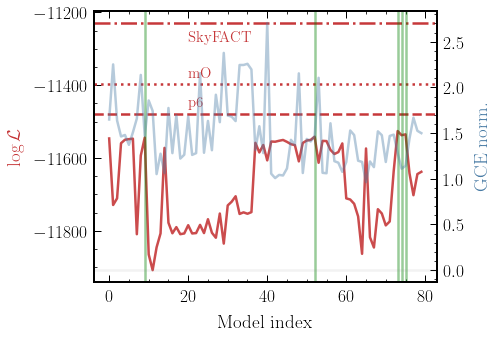

In [33]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list) * (~mask_roi).sum())
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='--', label='p6')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls=':', label='mO')
ax1.axhline(ll_SF * (~mask_roi).sum(), color=cols_default[0], ls='-.', label='SkyFACT')
ax1.text(20, ll_p6*(~mask_roi).sum()+20, 'p6', fontsize=15, c=cols_default[0])
ax1.text(20, ll_mO*(~mask_roi).sum()+20, 'mO', fontsize=15, c=cols_default[0])
ax1.text(20, ll_SF*(~mask_roi).sum()-50, 'SkyFACT', fontsize=15, c=cols_default[0])

for i in max_indices:
    ax1.axvline(x=i, color='green', alpha=0.4)

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1);
#ax1.legend()

In [34]:
# save best templates
for i, dif in enumerate(dif_names):
    
    if i in max_indices:
        for dif_type in ['pi0', 'bremss', 'ICS']:
            file = fits.open("{}/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(zenodo_dir, dif_type, dif))

            # The Zenodo maps are given in E^2 dN/dE; convert them to just expected intensity

            phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
            n_pix_edge = int((30 - extent) / pixel_size_data)
            n_pix_total = int(2 * extent / pixel_size_data)
            phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
            b = phi.shape[1] // upsample_factor
            phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
            phi *= np.deg2rad(pixel_size_target) ** 2
            phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
            #phi /= 1e3
            np.save(f'../data/external/RotT/{dif_type}_{dif}.npy', phi[:, ::-1])

## Expected log likelihood

$$-\frac{1}{2}\log(2\pi n)-\frac{1}{12n}<\log P(n,n)<-\frac{1}{2}\log(2\pi n)-\frac{1}{12n+1}$$

In [35]:
temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, 1e2*temp_SkyFACT_ICS, 1e2*temp_SkyFACT_pi0])
result = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi))

In [36]:
# expected perfect fit LL
best_fit_counts = np.sum(result.x[:,None,None] * temp_ary, axis=0)
n = best_fit_counts[~mask_roi]
print(f'{np.sum(-0.5*np.log(2*np.pi*n) - 1/(12*n)):.6f} {np.sum(-0.5*np.log(2*np.pi*n) - 1/(12*n+1)):.6f}')

-8970.498804 -8970.444705


In [37]:
temp_ary = np.array([best_fit_counts], dtype=np.int32)
-likelihood(np.array([1]), temp_ary[0], mask=mask_roi) * np.sum(~mask_roi)

-8933.61211063597

## Quadrants

In [38]:
ll_list_quadrants = []
opt_list_quadrants = []
ll_map_list_quadrants = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("{}/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(zenodo_dir, dif_type, dif))
        
        # The Zenodo maps are given ni E^2 dN/dE; convert them to just expected intensity
        
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target) ** 2
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        #phi /= 1e3
        phi = phi[:, ::-1]
        
        # Create quadrant templates
        
        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), :int(n_pixels / 2)] = phi[:int(n_pixels / 2), :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), int(n_pixels / 2):] = phi[:int(n_pixels / 2), int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, :int(n_pixels / 2)] = phi[int(n_pixels / 2):, :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, int(n_pixels / 2):] = phi[int(n_pixels / 2):, int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)
    
    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)

    opt_list_quadrants.append(opt)
    ll_list_quadrants.append(ll_data) 
    ll_map_list_quadrants.append(ll_map) 

  0%|          | 0/80 [00:00<?, ?it/s]

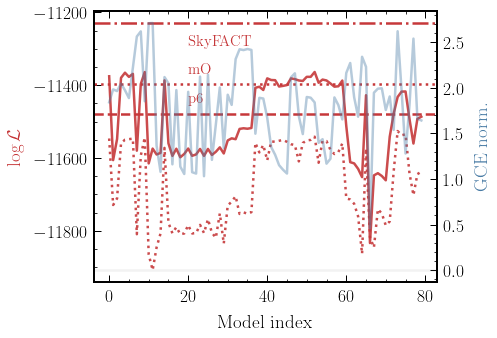

In [39]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='--', label='p6')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls=':', label='mO')
ax1.axhline(ll_SF * (~mask_roi).sum(), color=cols_default[0], ls='-.', label='SkyFACT')
ax1.text(20, ll_p6*(~mask_roi).sum()+30, 'p6', fontsize=15, c=cols_default[0])
ax1.text(20, ll_mO*(~mask_roi).sum()+30, 'mO', fontsize=15, c=cols_default[0])
ax1.text(20, ll_SF*(~mask_roi).sum()-60, 'SkyFACT', fontsize=15, c=cols_default[0])

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

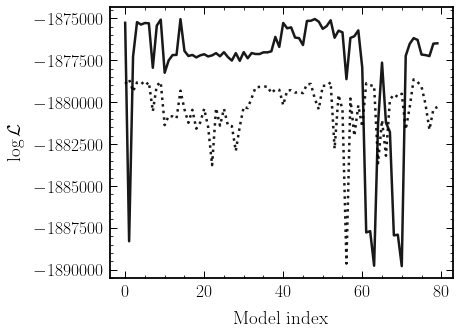

In [40]:
logl_paper = pd.read_csv("{}/ZENODO_FILES/GCE_Models_LogLikelihoods_2021_DMprofiles_October_GCE_vs_Background.dat".format(zenodo_dir), skiprows=1, header=None, delim_whitespace=True)

fig, ax1 = plt.subplots()

ax1.plot(logl_paper[1], color='k')
ax1.plot(logl_paper[5], color='k', ls=':')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$");

In [41]:
logl_paper[0][np.argsort(logl_paper[1])[-4:]]

52    LIII
9        X
14      XV
48    XLIX
Name: 0, dtype: object

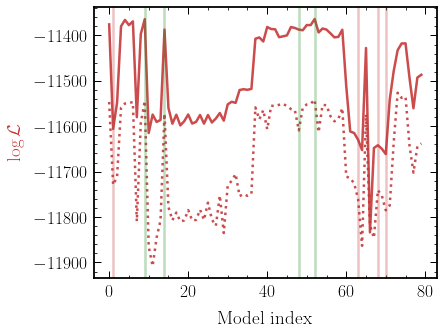

In [42]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
# ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
# ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

# ax2 = ax1.twinx()
# ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
# ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

for idx in np.argsort(logl_paper[1])[:4]:
    plt.axvline(idx, alpha=0.3)
    
for idx in np.argsort(logl_paper[1])[-4:]:
    plt.axvline(idx, color='forestgreen', alpha=0.3)

## Remove badly-fit pixels

Text(0.5, 1.0, 'Badly-fit pixels')

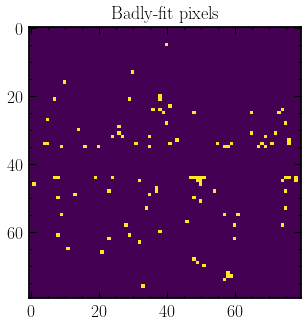

In [43]:
bad_pixels = np.zeros((n_pixels, n_pixels))

for ll_map in ll_map_list_quadrants:
    test_mask = ll_map < -8  # LL treshold at which to remove pixel
    bad_pixels += test_mask
    
bad_pixels = bad_pixels > 0
plt.imshow(bad_pixels)
plt.title("Badly-fit pixels")

In [44]:
ll_list_quadrants_badexcluded = []
for ll_map in ll_map_list_quadrants:
    ll_list_quadrants_badexcluded.append(ll_map.flatten()[~bad_pixels.flatten()].sum())

Text(0.5, 1.0, 'Best fit model')

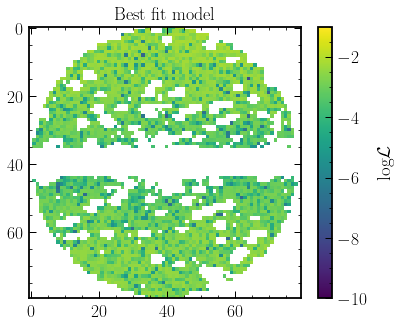

In [45]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-10, vmax=-1)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Best fit model")

Text(0.5, 1.0, 'Worst fit model')

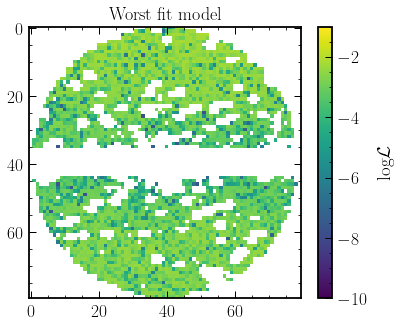

In [46]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-10, vmax=-1)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Worst fit model")

Text(0.5, 1.0, 'Difference between best- and worst-fit models')

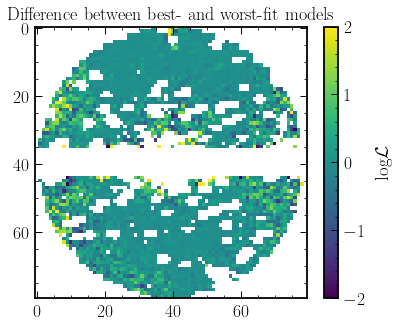

In [47]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))] - ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-2, vmax=2)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Difference between best- and worst-fit models")

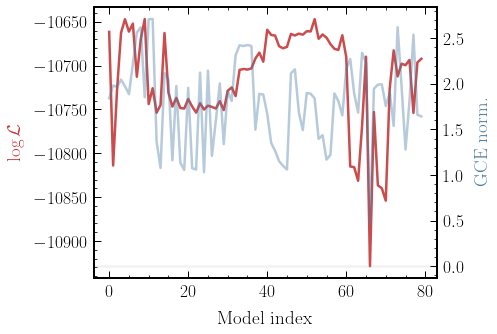

In [48]:
fig, ax1 = plt.subplots()

ax1.plot(ll_list_quadrants_badexcluded)

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)